In [1]:
#Tenure Group and customer count in each group
import pandas as pd
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
)
print(df[['tenure', 'TenureGroup']])
print("\nTenure Group Distribution:")
print(df['TenureGroup'].value_counts())

#Average Revenue Per Month
import pandas as pd
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
df['AvgRevenue'] = df['TotalCharges'] / (df['tenure'] + 1)
print(df[['tenure', 'TotalCharges', 'AvgRevenue']].head(50))

#Long-Term Customer
import pandas as pd
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
df['LongTermCustomer'] = df['tenure'].apply(
    lambda x: 1 if x > 24 else 0
)
print(df[['tenure', 'LongTermCustomer']])
print("\nLong-Term Customer Distribution:")
print(df['LongTermCustomer'].value_counts())

#Remove Customer ID
import pandas as pd
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
df.drop('customerID', axis=1, inplace=True)

      tenure TenureGroup
0          0        0-12
1          0        0-12
2          0        0-12
3          0        0-12
4          0        0-12
...      ...         ...
7038      72       49-72
7039      72       49-72
7040      72       49-72
7041      72       49-72
7042      72       49-72

[7043 rows x 2 columns]

Tenure Group Distribution:
TenureGroup
49-72    2239
0-12     2186
25-48    1594
13-24    1024
Name: count, dtype: int64
    tenure  TotalCharges  AvgRevenue
0        0          0.00       0.000
1        0          0.00       0.000
2        0          0.00       0.000
3        0          0.00       0.000
4        0          0.00       0.000
5        0          0.00       0.000
6        0          0.00       0.000
7        0          0.00       0.000
8        0          0.00       0.000
9        0          0.00       0.000
10       0          0.00       0.000
11       1         29.85      14.925
12       1         39.65      19.825
13       1         20.15      10.07

In [2]:
## Encode categorical columns
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
print("===== Categorical Columns =====")
print(df.select_dtypes(include=['object', 'string']).columns)
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col].astype(str))
print("\n===== Dataset After Encoding =====")
print(df.head(10))
print("\n===== Data Types After Encoding =====")
print(df.dtypes)
df.to_excel(r"C:\Users\abc\Documents\Customer_Churn_Encoded.xlsx", index=False)




#Separate Features and Target
import pandas as pd
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
# Separate Features (Independent Variables)
X = df.drop('Churn', axis=1)
# Separate Target Variable (Dependent Variable)
y = df['Churn']
print("===== FEATURES (X) =====")
print(X.head())
print("\n===== TARGET VARIABLE (y) =====")
print(y.head())
print("\n===== SHAPE OF FEATURES AND TARGET =====")
print("Features (X):", X.shape)
print("Target (y):", y.shape)


#Train-Test Split
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):", X_test.shape)
print("Training Target (y_train):", y_train.shape)
print("Testing Target (y_test):", y_test.shape)


#Logistic Regression
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col].astype(str))
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train Logistic Regression Model
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# Model Evaluation
print("===== Logistic Regression Results =====")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))


#Random Forest
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
df.drop('customerID', axis=1, inplace=True)
le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("===== RANDOM FOREST RESULTS =====\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


#XGBOOST Model
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
df.drop('customerID', axis=1, inplace=True)
le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# XGBoost Model
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print("===== XGBOOST RESULTS =====\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


#Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
print("\n===== MODEL EVALUATION =====\n")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Precision
precision = precision_score(y_test, y_pred)
print("\nPrecision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

# Full Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

===== Categorical Columns =====
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

===== Dataset After Encoding =====
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        3118       0              0        1           1       0   
1        2176       1              0        0           1       0   
2        4054       0              0        1           1       0   
3        3052       1              0        1           1       0   
4         945       0              0        1           1       0   
5        5433       1              0        1           1       0   
6        2250       1              0        1           1       0   
7        1731       0              0        1           1       0   
8

C:\Users\abc\PycharmProjects\PythonProject3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\abc\AppData\Local\Temp\ipykernel_3612\3920034639.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


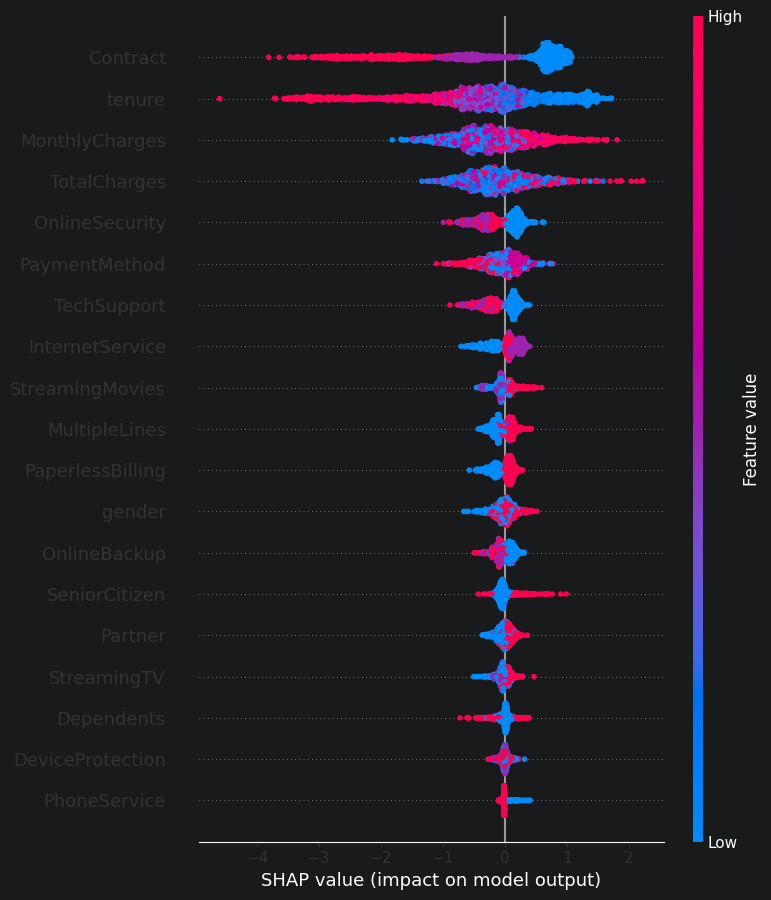

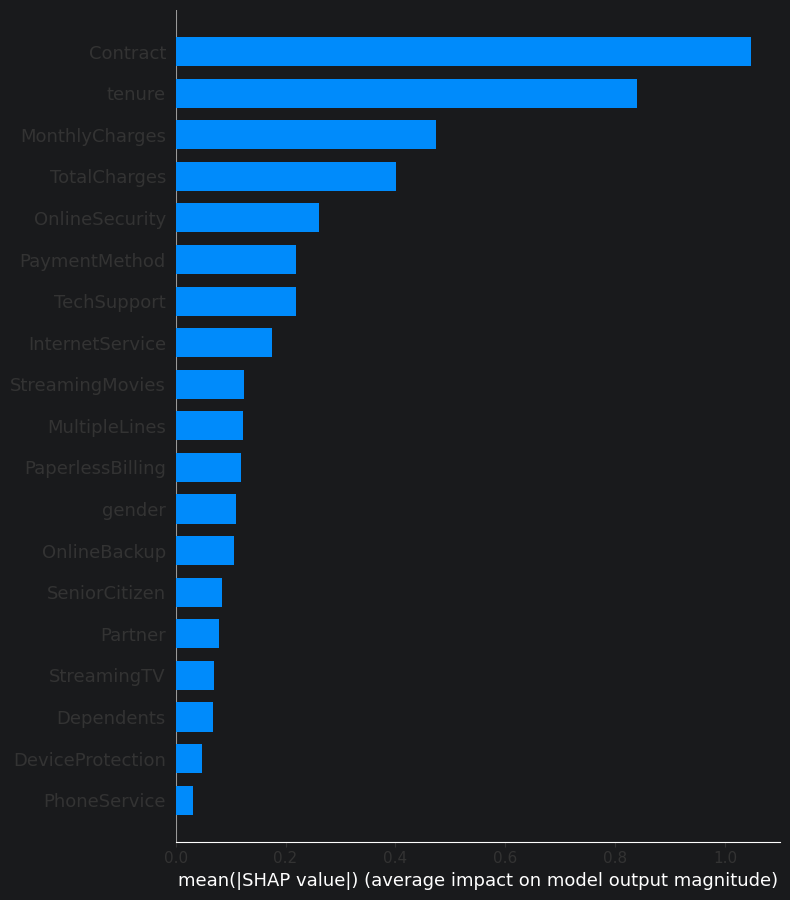

In [3]:
import shap
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df = pd.read_excel(r"C:\Users\abc\Documents\Customer Churn Prediction & Lifetime Value (1) cleaned dataset.xlsx")
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# TRAIN MODEL
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
# SHAP VALUES

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
# PLOT
shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")